# 07 — Baseline Decision Tree (clasificacion binaria)

**Responsable:** Edwin.

**Objetivo:** construir el **baseline oficial del proyecto** utilizando clasificacion binaria
(Normal/Ataque) sobre `data/processed/dataset_limpio.csv`, siguiendo el protocolo definido en
la tarea del equipo y en `reports/decisiones_preparacion.md` (secciones C, H, I):

- Target: `y_bin` (0 = Normal, 1 = Ataque), construido en este notebook (no existe todavia en
  ningun CSV). `Attack_type` se conserva en el DataFrame solo para trazabilidad.
- Comparar una variante **con** variables leaky (`id.orig_p`, `id.resp_p`, `proto`, `service`)
  y una variante **sin** ellas.
- `class_weight="balanced"`, split 80/20 estratificado (`stratify=y_bin`), `StratifiedKFold`
  sobre train, test reservado para el reporte final, `random_state=42` en todo.
- Busqueda de hiperparametros (`GridSearchCV`) **solo sobre la variante sin leaky** (decision
  de alcance documentada en `docs/baseline_decision_tree.md`), comparando baseline inicial vs
  modelo ajustado.


In [1]:
import os
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, average_precision_score,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## 1. Carga del dataset limpio

In [2]:
DATA_PATH = "../data/processed/dataset_limpio.csv"
df = pd.read_csv(DATA_PATH, index_col=0)

print("Shape:", df.shape)
print("Nulos totales:", df.isna().sum().sum())
assert df.isna().sum().sum() == 0, "Se esperaba un dataset sin nulos (ya validado en 03/05)."


Shape: (117922, 37)
Nulos totales: 0


## 2. Construccion y verificacion de `y_bin`

Formula oficial documentada en `reports/decisiones_preparacion.md` (C1) y
`docs/conceptos_proyecto.md`: normal = trafico de los 3 dispositivos IoT legitimos; ataque =
el resto. `Attack_type` se conserva en `df` solo para trazabilidad (no se usa como feature ni
como target del modelo).


In [3]:
NORMAL_CLASSES = {"MQTT_Publish", "Thing_Speak", "Wipro_bulb"}
y_bin = (~df["Attack_type"].isin(NORMAL_CLASSES)).astype(int)
y_bin.name = "y_bin"

print("Distribucion de y_bin (0 = Normal, 1 = Ataque):")
print(y_bin.value_counts())
print()
print((y_bin.value_counts(normalize=True) * 100).round(2).astype(str) + " %")


Distribucion de y_bin (0 = Normal, 1 = Ataque):
y_bin
1    105907
0     12015
Name: count, dtype: int64

y_bin
1    89.81 %
0    10.19 %
Name: proportion, dtype: object


## 3. Variables leaky vs no-leaky (igual que en el baseline multiclase anterior)

In [4]:
TARGET = "Attack_type"  # se mantiene en df por trazabilidad, no entra a X ni es el target
LEAKY_NUM = ["id.orig_p", "id.resp_p"]
LEAKY_CAT = ["proto", "service"]
BASE_NUM = [c for c in df.columns if c not in [TARGET, *LEAKY_NUM, *LEAKY_CAT]]

print(f"Features base (no leaky): {len(BASE_NUM)}")
print(f"Features leaky numericas: {LEAKY_NUM}")
print(f"Features leaky categoricas: {LEAKY_CAT}")

X = df.drop(columns=[TARGET])


Features base (no leaky): 32
Features leaky numericas: ['id.orig_p', 'id.resp_p']
Features leaky categoricas: ['proto', 'service']


## 4. Split 80/20 estratificado sobre `y_bin`

`stratify=y_bin` (no `Attack_type`) — pedido explicito de la tarea, ya que el problema oficial
es binario.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.20, random_state=RANDOM_STATE, stratify=y_bin
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print()
print("Proporcion de clases en train:")
print(y_train.value_counts(normalize=True).round(4))


Train: (94337, 36) Test: (23585, 36)

Proporcion de clases en train:
y_bin
1    0.8981
0    0.1019
Name: proportion, dtype: float64


## 5. `build_preprocessor(include_leaky)` + pipeline

Mismo diseno que el baseline multiclase anterior (`notebooks/07_baseline_decision_tree_old.ipynb`):
el split ya ocurrio arriba, y el `OneHotEncoder` se ajusta solo sobre train dentro del
`Pipeline` (orden anti-leakage). El arbol inicial se deja **sin restriccion de profundidad**
a proposito (caracter diagnostico, pedido explicito de la tarea).


In [6]:
def build_preprocessor(include_leaky: bool) -> ColumnTransformer:
    if include_leaky:
        num_cols = BASE_NUM + LEAKY_NUM
        cat_cols = LEAKY_CAT
    else:
        num_cols = BASE_NUM
        cat_cols = []

    transformers = [("num", "passthrough", num_cols)]
    if cat_cols:
        transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols))
    return ColumnTransformer(transformers)


def build_pipeline(include_leaky: bool, **tree_kwargs) -> Pipeline:
    params = {"class_weight": "balanced", "random_state": RANDOM_STATE}
    params.update(tree_kwargs)
    return Pipeline([
        ("prep", build_preprocessor(include_leaky)),
        ("clf", DecisionTreeClassifier(**params)),
    ])


VARIANTS = {"con_leaky": True, "sin_leaky": False}
pipelines = {name: build_pipeline(inc) for name, inc in VARIANTS.items()}


## 6. Entrenamiento inicial de ambas variantes + tiempos de entrenamiento y prediccion

In [7]:
fit_times = {}
predict_times = {}
for name, pipe in pipelines.items():
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    fit_times[name] = time.perf_counter() - t0

    t0 = time.perf_counter()
    pipe.predict(X_test)
    predict_times[name] = time.perf_counter() - t0

    print(f"{name}: fit_time = {fit_times[name]:.3f} s | predict_time = {predict_times[name]:.4f} s")


con_leaky: fit_time = 1.120 s | predict_time = 0.0302 s


sin_leaky: fit_time = 0.408 s | predict_time = 0.0115 s


## 7. Validacion cruzada estratificada (`StratifiedKFold`)

5 folds sobre train (el test permanece reservado). `average_precision` es el nombre de scoring
nativo de sklearn para PR-AUC en problemas binarios.


In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "f1_macro", "average_precision"]

cv_results = {}
for name, inc in VARIANTS.items():
    pipe = build_pipeline(inc)  # instancia fresca, no reusar el arbol ya ajustado
    cv_results[name] = cross_validate(
        pipe, X_train, y_train, cv=skf, scoring=scoring,
        return_train_score=True, n_jobs=-1,
    )

cv_summary_rows = []
for name, res in cv_results.items():
    row = {"variante": name}
    for metric in scoring:
        row[f"cv_val_{metric}_mean"] = res[f"test_{metric}"].mean()
        row[f"cv_val_{metric}_std"] = res[f"test_{metric}"].std()
        row[f"cv_train_{metric}_mean"] = res[f"train_{metric}"].mean()
    row["cv_fit_time_mean_s"] = res["fit_time"].mean()
    cv_summary_rows.append(row)

cv_summary = pd.DataFrame(cv_summary_rows).set_index("variante")
cv_summary


,cv_val_accuracy_mean,cv_val_accuracy_std,cv_train_accuracy_mean,cv_val_precision_mean,cv_val_precision_std,cv_train_precision_mean,cv_val_recall_mean,cv_val_recall_std,cv_train_recall_mean,cv_val_f1_mean,cv_val_f1_std,cv_train_f1_mean,cv_val_f1_macro_mean,cv_val_f1_macro_std,cv_train_f1_macro_mean,cv_val_average_precision_mean,cv_val_average_precision_std,cv_train_average_precision_mean,cv_fit_time_mean_s
variante,,,,,,,,,,,,,,,,,,,
con_leaky,0.998346,0.000324,0.999992,0.99902,0.000199,1.000000,0.999138,0.000213,0.999991,0.999079,0.000180,0.999996,0.995480,0.000885,0.999978,0.998934,0.000211,1.0,1.996940
sin_leaky,0.998219,0.000499,0.999889,0.99882,0.000338,0.999976,0.999197,0.000333,0.999900,0.999009,0.000278,0.999938,0.995127,0.001364,0.999696,0.998748,0.000348,1.0,0.731602


## 8. Evaluacion del baseline inicial en el test reservado

In [9]:
def evaluate_on_test(pipe, name, label="test"):
    t0 = time.perf_counter()
    y_pred = pipe.predict(X_test)
    predict_time = time.perf_counter() - t0
    y_proba = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "pr_auc": average_precision_score(y_test, y_proba),
        "predict_time_s": predict_time,
    }
    print(f"\n=== {name} - classification_report ({label}) ===")
    print(classification_report(y_test, y_pred, target_names=["Normal(0)", "Ataque(1)"], zero_division=0))
    return metrics, y_pred

test_metrics = {}
test_preds = {}
for name, pipe in pipelines.items():
    metrics, y_pred = evaluate_on_test(pipe, name)
    test_metrics[name] = metrics
    test_preds[name] = y_pred



=== con_leaky - classification_report (test) ===
              precision    recall  f1-score   support

   Normal(0)       0.99      0.99      0.99      2403
   Ataque(1)       1.00      1.00      1.00     21182

    accuracy                           1.00     23585
   macro avg       1.00      0.99      1.00     23585
weighted avg       1.00      1.00      1.00     23585


=== sin_leaky - classification_report (test) ===
              precision    recall  f1-score   support

   Normal(0)       0.99      0.99      0.99      2403
   Ataque(1)       1.00      1.00      1.00     21182

    accuracy                           1.00     23585
   macro avg       1.00      0.99      1.00     23585
weighted avg       1.00      1.00      1.00     23585



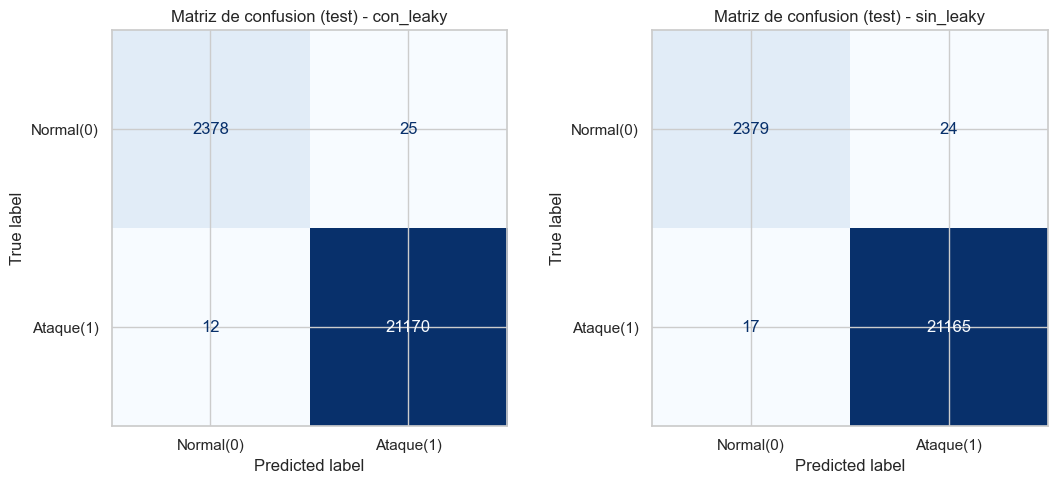

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (name, y_pred) in zip(axes, test_preds.items()):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal(0)", "Ataque(1)"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Matriz de confusion (test) - {name}")
plt.tight_layout()
plt.show()


## 9. Tabla comparativa del baseline inicial (con leaky vs sin leaky)

In [11]:
rows = []
for name in VARIANTS:
    clf = pipelines[name].named_steps["clf"]
    rows.append({
        "variante": name,
        "accuracy": test_metrics[name]["accuracy"],
        "precision": test_metrics[name]["precision"],
        "recall": test_metrics[name]["recall"],
        "f1": test_metrics[name]["f1"],
        "f1_macro": test_metrics[name]["f1_macro"],
        "pr_auc": test_metrics[name]["pr_auc"],
        "cv_f1_macro_mean": cv_summary.loc[name, "cv_val_f1_macro_mean"],
        "cv_f1_macro_std": cv_summary.loc[name, "cv_val_f1_macro_std"],
        "fit_time_s": fit_times[name],
        "predict_time_s": predict_times[name],
        "tree_depth": clf.get_depth(),
        "tree_leaves": clf.get_n_leaves(),
    })

baseline_comparison = pd.DataFrame(rows).set_index("variante")
baseline_comparison.round(4)


,accuracy,precision,recall,f1,f1_macro,pr_auc,cv_f1_macro_mean,cv_f1_macro_std,fit_time_s,predict_time_s,tree_depth,tree_leaves
variante,,,,,,,,,,,,
con_leaky,0.9984,0.9988,0.9994,0.9991,0.9957,0.9988,0.9955,0.0009,1.1202,0.0302,21,196
sin_leaky,0.9983,0.9989,0.9992,0.9990,0.9952,0.9988,0.9951,0.0014,0.4080,0.0115,23,207


## 10. Importancia de variables (tabla + grafica)

Si las columnas leaky dominan el ranking en la variante *con leaky*, es otra confirmacion de
que estan aportando informacion que un IDS real no tendria disponible.



Top 10 - con_leaky
flow_duration            0.9086
flow_pkts_payload.min    0.0177
bwd_init_window_size     0.0156
bwd_pkts_tot             0.0115
fwd_header_size_max      0.0099
fwd_subflow_bytes        0.0098
flow_CWR_flag_count      0.0058
flow_pkts_payload.std    0.0031
bwd_pkts_payload.min     0.0016
id.resp_p                0.0016
dtype: float64

Top 10 - sin_leaky
flow_duration            0.9094
flow_pkts_payload.min    0.0187
bwd_init_window_size     0.0162
bwd_pkts_tot             0.0115
fwd_subflow_bytes        0.0103
fwd_header_size_max      0.0100
flow_CWR_flag_count      0.0058
flow_pkts_payload.std    0.0038
flow_pkts_payload.max    0.0030
bwd_pkts_payload.min     0.0018
dtype: float64


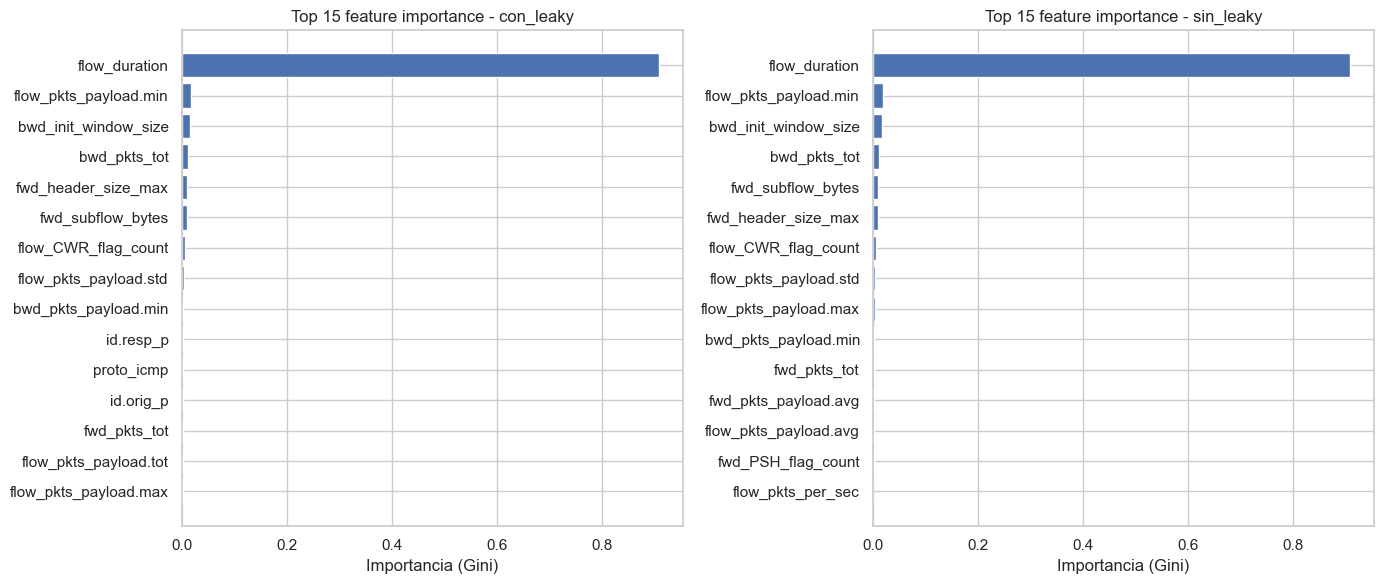

In [12]:
def get_feature_importances(pipe):
    prep = pipe.named_steps["prep"]
    clf = pipe.named_steps["clf"]
    names = [n.split("__", 1)[-1] for n in prep.get_feature_names_out()]
    return pd.Series(clf.feature_importances_, index=names).sort_values(ascending=False)

importances = {name: get_feature_importances(pipe) for name, pipe in pipelines.items()}

for name, imp in importances.items():
    print(f"\nTop 10 - {name}")
    print(imp.head(10).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, imp) in zip(axes, importances.items()):
    top = imp.head(15)[::-1]
    ax.barh(top.index, top.values, color="#4C72B0")
    ax.set_title(f"Top 15 feature importance - {name}")
    ax.set_xlabel("Importancia (Gini)")
plt.tight_layout()
plt.show()


## 11. Diagnostico de sobreajuste del baseline inicial (train vs CV vs test)

In [13]:
overfit_rows = []
for name in VARIANTS:
    clf = pipelines[name].named_steps["clf"]
    train_pred = pipelines[name].predict(X_train)
    overfit_rows.append({
        "variante": name,
        "train_f1_macro": f1_score(y_train, train_pred, average="macro", zero_division=0),
        "cv_val_f1_macro": cv_summary.loc[name, "cv_val_f1_macro_mean"],
        "test_f1_macro": test_metrics[name]["f1_macro"],
        "tree_depth": clf.get_depth(),
        "tree_leaves": clf.get_n_leaves(),
    })

overfit_df = pd.DataFrame(overfit_rows).set_index("variante")
overfit_df["gap_train_vs_cv"] = overfit_df["train_f1_macro"] - overfit_df["cv_val_f1_macro"]
overfit_df.round(4)


,train_f1_macro,cv_val_f1_macro,test_f1_macro,tree_depth,tree_leaves,gap_train_vs_cv
variante,,,,,,
con_leaky,1.0000,0.9955,0.9957,21,196,0.0045
sin_leaky,0.9997,0.9951,0.9952,23,207,0.0046


## 12. Busqueda de hiperparametros (`GridSearchCV`, solo variante sin leaky)

**Decision de alcance:** el grid search corre unicamente sobre la variante **sin leaky** (la
recomendada para produccion) para no duplicar el paso mas costoso en una variante que de
todas formas no se usaria en un IDS real.

**Decision de herramienta (`GridSearchCV` en vez de Optuna):** ya viene con scikit-learn (no
agrega dependencias nuevas), el grid de 4 hiperparametros es pequeno y perfectamente
abarcable de forma exhaustiva, y es determinista/reproducible sin hiperparametros propios que
ajustar (a diferencia de un `study` de Optuna).

**Decision de scoring (`f1_macro`):** da igual peso a ambas clases, coherente con
`class_weight="balanced"`, y evita premiar un modelo degenerado que prediga "todo ataque"
(maximizaria `recall` trivialmente pero no `f1_macro`).

El test **no se toca** durante esta busqueda — solo `X_train`/`y_train`.


In [14]:
param_grid = {
    "clf__max_depth": [3, 5, 8, 10, 15, 20, None],
    "clf__min_samples_split": [2, 10, 20, 50],
    "clf__min_samples_leaf": [1, 5, 10, 20],
    "clf__criterion": ["gini", "entropy"],
}

base_pipeline_sin_leaky = build_pipeline(include_leaky=False)

grid_search = GridSearchCV(
    base_pipeline_sin_leaky,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=skf,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

t0 = time.perf_counter()
grid_search.fit(X_train, y_train)
grid_search_time = time.perf_counter() - t0

print(f"GridSearchCV: {len(grid_search.cv_results_['params'])} combinaciones, {grid_search_time:.1f} s totales")
print("Mejores hiperparametros:", grid_search.best_params_)
print(f"Mejor f1_macro (CV, train): {grid_search.best_score_:.4f}")


GridSearchCV: 224 combinaciones, 128.3 s totales
Mejores hiperparametros: {'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
Mejor f1_macro (CV, train): 0.9951


### Importancia relativa de cada hiperparametro (barrido marginal sobre `cv_results_`)

In [15]:
cv_results_df = pd.DataFrame(grid_search.cv_results_)

param_cols = [c for c in cv_results_df.columns if c.startswith("param_clf__")]
marginal_effect = {}
for col in param_cols:
    grouped = cv_results_df.groupby(col)["mean_test_score"].mean().sort_values(ascending=False)
    marginal_effect[col.replace("param_clf__", "")] = grouped.max() - grouped.min()
    print(f"\n{col.replace('param_clf__', '')} (promedio de f1_macro por valor):")
    print(grouped.round(4))

print("\nRango (max-min) de f1_macro promedio por hiperparametro (cuanto 'mueve' cada uno):")
print(pd.Series(marginal_effect).sort_values(ascending=False).round(4))



criterion (promedio de f1_macro por valor):
param_clf__criterion
gini       0.9814
entropy    0.9776
Name: mean_test_score, dtype: float64

max_depth (promedio de f1_macro por valor):
param_clf__max_depth
20    0.9883
15    0.9882
10    0.9877
8     0.9870
5     0.9823
3     0.9348
Name: mean_test_score, dtype: float64

min_samples_leaf (promedio de f1_macro por valor):
param_clf__min_samples_leaf
1     0.9814
5     0.9799
10    0.9791
20    0.9776
Name: mean_test_score, dtype: float64

min_samples_split (promedio de f1_macro por valor):
param_clf__min_samples_split
2     0.9803
10    0.9800
20    0.9796
50    0.9782
Name: mean_test_score, dtype: float64

Rango (max-min) de f1_macro promedio por hiperparametro (cuanto 'mueve' cada uno):
max_depth            0.0535
criterion            0.0038
min_samples_leaf     0.0038
min_samples_split    0.0021
dtype: float64


## 13. Evaluacion del modelo ajustado en el test reservado

In [16]:
best_pipeline = grid_search.best_estimator_

t0 = time.perf_counter()
best_pipeline.fit(X_train, y_train)  # ya esta ajustado por refit=True, se re-mide fit_time de forma limpia
tuned_fit_time = time.perf_counter() - t0

tuned_metrics, tuned_pred = evaluate_on_test(best_pipeline, "sin_leaky_ajustado", label="test")
tuned_predict_time = tuned_metrics["predict_time_s"]

tuned_clf = best_pipeline.named_steps["clf"]
print(f"\nProfundidad: {tuned_clf.get_depth()} | Hojas: {tuned_clf.get_n_leaves()}")



=== sin_leaky_ajustado - classification_report (test) ===
              precision    recall  f1-score   support

   Normal(0)       0.99      0.99      0.99      2403
   Ataque(1)       1.00      1.00      1.00     21182

    accuracy                           1.00     23585
   macro avg       1.00      0.99      1.00     23585
weighted avg       1.00      1.00      1.00     23585


Profundidad: 23 | Hojas: 207


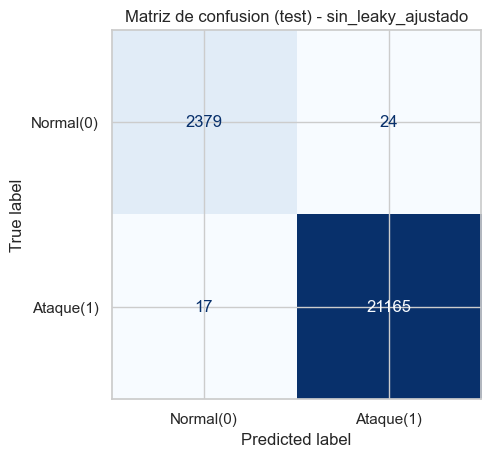

In [17]:
cm = confusion_matrix(y_test, tuned_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal(0)", "Ataque(1)"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Matriz de confusion (test) - sin_leaky_ajustado")
plt.show()


## 14. Comparacion: baseline inicial (sin leaky) vs modelo ajustado

In [18]:
train_pred_tuned = best_pipeline.predict(X_train)
tuned_train_f1_macro = f1_score(y_train, train_pred_tuned, average="macro", zero_division=0)

comparison_rows = [
    {
        "modelo": "baseline_inicial_sin_leaky",
        "accuracy": test_metrics["sin_leaky"]["accuracy"],
        "precision": test_metrics["sin_leaky"]["precision"],
        "recall": test_metrics["sin_leaky"]["recall"],
        "f1": test_metrics["sin_leaky"]["f1"],
        "f1_macro": test_metrics["sin_leaky"]["f1_macro"],
        "pr_auc": test_metrics["sin_leaky"]["pr_auc"],
        "train_f1_macro": overfit_df.loc["sin_leaky", "train_f1_macro"],
        "gap_train_vs_test_f1_macro": overfit_df.loc["sin_leaky", "train_f1_macro"] - test_metrics["sin_leaky"]["f1_macro"],
        "fit_time_s": fit_times["sin_leaky"],
        "predict_time_s": predict_times["sin_leaky"],
        "tree_depth": overfit_df.loc["sin_leaky", "tree_depth"],
        "tree_leaves": overfit_df.loc["sin_leaky", "tree_leaves"],
    },
    {
        "modelo": "sin_leaky_ajustado",
        "accuracy": tuned_metrics["accuracy"],
        "precision": tuned_metrics["precision"],
        "recall": tuned_metrics["recall"],
        "f1": tuned_metrics["f1"],
        "f1_macro": tuned_metrics["f1_macro"],
        "pr_auc": tuned_metrics["pr_auc"],
        "train_f1_macro": tuned_train_f1_macro,
        "gap_train_vs_test_f1_macro": tuned_train_f1_macro - tuned_metrics["f1_macro"],
        "fit_time_s": tuned_fit_time,
        "predict_time_s": tuned_predict_time,
        "tree_depth": tuned_clf.get_depth(),
        "tree_leaves": tuned_clf.get_n_leaves(),
    },
]

final_comparison = pd.DataFrame(comparison_rows).set_index("modelo")
final_comparison.round(4)


,accuracy,precision,recall,f1,f1_macro,pr_auc,train_f1_macro,gap_train_vs_test_f1_macro,fit_time_s,predict_time_s,tree_depth,tree_leaves
modelo,,,,,,,,,,,,
baseline_inicial_sin_leaky,0.9983,0.9989,0.9992,0.999,0.9952,0.9988,0.9997,0.0044,0.408,0.0115,23,207
sin_leaky_ajustado,0.9983,0.9989,0.9992,0.999,0.9952,0.9988,0.9997,0.0044,0.483,0.0129,23,207


## 15. Guardado del modelo final

Se persiste el **modelo ajustado** (ganador de `GridSearchCV`, variante sin leaky) — es el
resultado oficial de todo el proceso de esta tarea.


In [19]:
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

model_path = os.path.join(MODELS_DIR, "decision_tree_baseline.pkl")
joblib.dump(best_pipeline, model_path)
print(f"Modelo guardado en {model_path}")

loaded = joblib.load(model_path)
reload_pred = loaded.predict(X_test)
assert accuracy_score(y_test, reload_pred) == tuned_metrics["accuracy"]
print("Recarga verificada: metricas consistentes con el modelo ajustado de este notebook.")


Modelo guardado en ../models\decision_tree_baseline.pkl
Recarga verificada: metricas consistentes con el modelo ajustado de este notebook.


## 16. Resumen numerico (para trazabilidad de `docs/baseline_decision_tree.md`)

In [20]:
summary_dict = {
    "y_bin_distribution": (y_bin.value_counts(normalize=True) * 100).round(2).to_dict(),
    "baseline_comparison": baseline_comparison.round(4).to_dict(orient="index"),
    "cv_summary": cv_summary.round(4).to_dict(orient="index"),
    "overfit": overfit_df.round(4).to_dict(orient="index"),
    "top_importances_sin_leaky": importances["sin_leaky"].head(10).round(4).to_dict(),
    "top_importances_con_leaky": importances["con_leaky"].head(10).round(4).to_dict(),
    "grid_search": {
        "n_combinations": len(grid_search.cv_results_["params"]),
        "search_time_s": round(grid_search_time, 2),
        "best_params": grid_search.best_params_,
        "best_cv_f1_macro": round(grid_search.best_score_, 4),
        "marginal_effect_f1_macro": {k: round(v, 4) for k, v in marginal_effect.items()},
    },
    "final_comparison": final_comparison.round(4).to_dict(orient="index"),
}
print(json.dumps(summary_dict, indent=2, ensure_ascii=False, default=str))


{
  "y_bin_distribution": {
    "1": 89.81,
    "0": 10.19
  },
  "baseline_comparison": {
    "con_leaky": {
      "accuracy": 0.9984,
      "precision": 0.9988,
      "recall": 0.9994,
      "f1": 0.9991,
      "f1_macro": 0.9957,
      "pr_auc": 0.9988,
      "cv_f1_macro_mean": 0.9955,
      "cv_f1_macro_std": 0.0009,
      "fit_time_s": 1.1202,
      "predict_time_s": 0.0302,
      "tree_depth": 21,
      "tree_leaves": 196
    },
    "sin_leaky": {
      "accuracy": 0.9983,
      "precision": 0.9989,
      "recall": 0.9992,
      "f1": 0.999,
      "f1_macro": 0.9952,
      "pr_auc": 0.9988,
      "cv_f1_macro_mean": 0.9951,
      "cv_f1_macro_std": 0.0014,
      "fit_time_s": 0.408,
      "predict_time_s": 0.0115,
      "tree_depth": 23,
      "tree_leaves": 207
    }
  },
  "cv_summary": {
    "con_leaky": {
      "cv_val_accuracy_mean": 0.9983,
      "cv_val_accuracy_std": 0.0003,
      "cv_train_accuracy_mean": 1.0,
      "cv_val_precision_mean": 0.999,
      "cv_val_precisio

## 17. Conclusiones

### ¿Cual es el desempeno del Decision Tree para clasificacion binaria?

El baseline inicial **sin leaky** (misma configuracion que el modelo ajustado, ver mas abajo)
obtiene en el test reservado: accuracy 0.9983, precision 0.9989, recall 0.9992, F1 0.9990,
F1-macro 0.9952, PR-AUC 0.9988. En CV (5-fold estratificado sobre train): F1-macro promedio
**0.9951 ± 0.0014**. La matriz de confusion en test: TN=2379, FP=24, FN=17, TP=21165 — solo
**17 ataques no detectados de 21182** (0.08% de falsos negativos) y **24 falsas alarmas de
2403 normales** (1.0% de falsos positivos). El desempeno es notablemente mas alto que el del
baseline multiclase anterior (F1-macro ~0.93-0.97): separar 2 clases (Normal/Ataque) es un
problema bastante mas facil que distinguir 12 tipos de ataque especificos.

### ¿Que diferencia existe entre utilizar y no utilizar variables leaky?

Minima, a diferencia del caso multiclase (donde con-leaky ganaba por 1.6-2.3 pp). Aqui:
F1-macro test 0.9957 (con leaky) vs 0.9952 (sin leaky) — **apenas +0.05 pp**; F1-macro CV
0.9955 vs 0.9951 — +0.04 pp. La razon es clara al ver la importancia de variables:
`flow_duration` domina con ~90.9% de la importancia en **ambas** variantes, y `id.resp_p`
apenas aparece en el top 10 de la variante con leaky con 0.16% de importancia — el problema
binario ya esta practicamente resuelto por `flow_duration` solo, sin necesitar el atajo de
puertos/protocolo/servicio. Esto refuerza, con mas evidencia que en el caso multiclase, la
recomendacion de usar la variante **sin leaky**.

### ¿Que variables son mas importantes?

`flow_duration` domina de forma abrumadora (~90.9% en sin leaky, ~90.86% en con leaky), muy
por encima de todo lo demas. Le siguen, con importancia mucho menor: `flow_pkts_payload.min`
(1.9%), `bwd_init_window_size` (1.6%), `bwd_pkts_tot` (1.2%), `fwd_subflow_bytes` (1.0%),
`fwd_header_size_max` (1.0%). Es un cambio marcado respecto al baseline multiclase (donde
`fwd_last_window_size` lideraba con ~22%, mucho mas repartido entre variables). Una sola
variable explicando el 91% de la importancia es una senal a vigilar: probablemente refleja que
el trafico normal (dispositivos IoT legitimos con flujos sostenidos) tiene una duracion de
flujo estructuralmente distinta a la de los ataques (escaneos/floods, tipicamente mas cortos)
en este dataset especifico — no es un identificador tipo leaky, pero conviene que el equipo lo
tenga presente al interpretar el modelo (posible fragilidad si el patron de duracion de flujo
cambia en trafico nuevo).

### ¿El baseline presenta sobreajuste?

Mucho menor que en el caso multiclase. La brecha train(CV) vs validacion(CV) en F1-macro es de
solo **0.0045-0.0046** (vs 0.04-0.06 en el baseline multiclase), a pesar de que el arbol sigue
sin restriccion de profundidad (23 niveles, 207 hojas en la variante sin leaky). El problema
binario es lo bastante separable como para que el arbol, aunque crece libre, no termine
memorizando ruido de forma significativa.

### ¿Que hiperparametros influyen mas en el desempeno?

Del barrido marginal sobre `grid_search.cv_results_`: **`max_depth`** es, por mucho, el que
mas mueve el F1-macro promedio (rango de 0.0535 entre su mejor y peor valor evaluado) — muy
por encima de `min_samples_leaf` (0.0038), `criterion` (0.0038) y `min_samples_split` (0.0021),
que apenas cambian el resultado en este problema. Tiene sentido: limitar demasiado la
profundidad causa subajuste (el arbol no alcanza a separar bien), mientras que el criterio de
division (gini/entropy) y los minimos de muestras por nodo/hoja son ajustes mucho mas finos
que no importan tanto cuando el problema ya es muy separable.

### ¿El modelo ajustado mejora respecto al baseline inicial?

**No** — y es un resultado real, no un error. `GridSearchCV` (224 combinaciones × 5 folds)
eligio como mejores hiperparametros `max_depth=None, min_samples_split=2, min_samples_leaf=1,
criterion="gini"`, que es **exactamente la configuracion sin restricciones** del baseline
inicial (misma profundidad 23, mismas 207 hojas, mismas metricas de test hasta el cuarto
decimal). La explicacion es consistente con el punto anterior: como el sobreajuste del
baseline inicial ya era minimo (brecha ~0.0045), no habia margen para que podar el arbol
mejorara la generalizacion — de hecho, cualquier `max_depth` restrictivo bajaba el F1-macro
promedio en la busqueda, razon por la cual `max_depth` fue el hiperparametro con mayor efecto
marginal. Conclusion: para este problema binario especifico, el baseline sin restricciones ya
es practicamente optimo; la busqueda de hiperparametros sirvio para **confirmarlo
empiricamente**, no para superarlo.

### ¿Que dificultades aparecieron durante el entrenamiento?

- Mismo ruido inofensivo de `joblib`/`loky` (*resource tracker*, `KeyError` en limpieza de
  carpetas de *memmapping*) visto en el baseline multiclase, tanto en `cross_validate` como en
  `GridSearchCV` con `n_jobs=-1` en Windows — no afecto el resultado.
- El `GridSearchCV` (224 combinaciones × 5 folds = 1120 ajustes) tomo **~128 segundos** —
  manejable, no fue necesario reducir el grid.
- A diferencia del baseline multiclase, aqui no hubo problema de clases extremadamente raras en
  la validacion cruzada (89.8%/10.2% es un desbalance mucho menos extremo que las clases de
  28-36 filas del caso de 12 clases), aunque la clase Normal (10.2%) se sigue manejando con
  `class_weight="balanced"` + `stratify=y_bin`.
- El hallazgo de que el "modelo ajustado" resulto identico al baseline inicial exigio una
  verificacion cuidadosa (revisar `grid_search.best_params_` y las metricas hasta varios
  decimales) para confirmar que no era un error de implementacion, sino un resultado
  legitimo del grid search.
